In [1]:
# possibly used packages
using QuadGK,LaTeXStrings,BenchmarkTools;
using LinearAlgebra,Roots;
using Plots;
gr(framestyle = :box, minorticks = 5, size=(400,300));
# default(framestyle = :box, minorticks = 5, size=(400,300));

Plots.GRBackend()

In [2]:
include("src/gem.jl");
using Main.Gem;

# Introduction
This notebook illustrates how to solve the following Coupled-channel Schrodinger equation using Gaussian-Expansion-Method as described in [Gaussian expansion method for few-body systems](https://www.sciencedirect.com/science/article/abs/pii/S0146641003900159?via%3Dihub).
\begin{equation}
[-\frac{\hbar^2}{2\mu_i}\bigtriangledown^2+\Delta E_i]\psi_i(\vec{r})+\sum_j V_{ij}\psi_j(\vec{r})=E\psi_i(\vec{r})
\end{equation}
or radially,i.e. $u_i(r)=r \psi_i(r)$,
\begin{equation}
[-\frac{\hbar^2}{2\mu_i}\frac{d^2}{dr^2}+\frac{\hbar^2l_i(l_i+1)}{2\mu_ir^2}+\Delta E_i]u_i+\sum_j V_{ij}u_j=Eu_i
\end{equation}
For a better understanding, the necessary ingredients will be explained next!

If we expand the wave function with given basis(we choose Gaussian basis functions here), i.e.
\begin{align}
\psi^{(i)}_{lm}(\vec{r})&=\sum_{n=1}^{n_{max}}c^{(i)}_{nl}\phi_{nlm}^{(i)}(\vec{r})\\
\phi_{nlm}^{(i)}(\vec{r})&=\phi_{nl}^{(i)}(r)Y_{lm}({\hat{r}})\\
\phi_{nl}^{(i)}(r)&=N_{nl_i}r^{l_i}e^{-\nu_n r^2}\\
N_{nl_i}&=(\frac{2^{l_i+2}(2\nu_n)^{l_i+3/2}}{\sqrt{\pi}(2l_i+1)!!})^{1/2}
\end{align}
In practice, the set of Gaussian size parameters($\nu_i$) works well when in geometric progression
\begin{align}
\nu_n&=\frac{1}{r_n^2}\\
r_n&=r_1a^{n-1}\\
\Rightarrow \nu_n&=\frac{1}{r_1^2}(\frac{r_1}{r_{n_{max}}})^{\frac{2(n-1)}{n_{max}-1}}
\end{align}
Thus, we adopt three parameters $\{n_{max},r_1,r_{n_{max}}\}$ to represent the gaussian basis set. 

Under such a basis, the Coupled-Channel Schrodinger equation turns to be a generalized matrix eigenvalue problem:
\begin{align}
\left[\begin{pmatrix}\Box^{(1)}& & \\&... &\\ & & \Box^{(n)}\end{pmatrix}
+\begin{pmatrix}\bigstar^{(11)}&...&..\\...&...&...\\...&...&\bigstar^{(nn)}\end{pmatrix}
+\begin{pmatrix}\Delta E_1\cdot \blacksquare^{(1)}& & \\&... &\\ & &\Delta E_n\cdot \blacksquare^{(n)}\end{pmatrix}\right]
\begin{pmatrix}c_1^{(1)}\\...\\c_{n_{nmax}}^{(n)}\end{pmatrix}=E\begin{pmatrix}c_1^{(1)}\\...\\c_{n_{nmax}}^{(n)}\end{pmatrix}
\end{align}

where $\Box$, $\bigstar$ and $\blacksquare$ refer to the submatrix of T- , V- and N matrix with their elements specified in the following,

\begin{align}
\Box^{(i)}_{n,n'}&=\langle\phi_{nlm}^G|-\frac{\hbar^2}{2\mu_i}\bigtriangledown^2|\phi_{n'lm}^G\rangle=\frac{\hbar^2}{\mu_i}\frac{(2l_i+3)\nu_n\nu_{n'}}{\nu_n+\nu_{n'}}(\frac{2\sqrt{\nu_n\nu_{n'}}}{\nu_n+\nu_{n'}})^{l_i+3/2}\\
\bigstar^{(ij)}_{n,n'}&=\langle\phi_{nlm}^G|V^{(ij)}|\phi_{n'lm}^G\rangle=N_{nl_i}N_{n'l_i}\int_0^{\infty}r^{2l_i}e^{-(\nu_n+\nu_{n'})r^2}V^{(ij)}(r)r^2dr\\
\blacksquare^{(i)}_{n,n'}&=\langle\phi_{nlm}^G|\phi_{n'lm}^G\rangle=(\frac{2\sqrt{\nu_n\nu_{n'}}}{\nu_n+\nu_{n'}})^{l_i+3/2}
\end{align}

## To use the script
1. **define your coupled-channel potential in the form**
    ```julia
    function potential(r,i,j;args1=...,args2=...)
    #some codes
    end
    ```
where the i,j are the channel number. remember to put all extra arguments into the optinal part.

2. **input the least information of your Schrodinger equation**

    Gaussian basis: *GemBasis*($n_{max}$ , $r_1$ , $r_{nmax}$)

    Hamiltonian: *GemHamiltonian*([$\mu_1$,...,$\mu_n$],[$\Delta E_1$,...,$\Delta E_n$],[$l_1$ ,..., $l_n$],potential)

    Hamiltonian model in GEM: *GemModel*(::GemHamiltonian,::GemBasis;hbar=...)






3. **solve the model**

    *gemsolve!(::GemModel,::GemHamiltonian,::GemBasis;args1=...,args2=...)*
4. **find out if there's a bound state**

    gemisbounded(::GemModel)
5. **ploting the result**

    *gemplot(::GemModel,::GemHamiltonian,::GemBasis,cl,index,rmin,rmax;kwargs...)* (cl is the cl-th channel, index is the index of eigenvalues of the above matrix equation), *gemplot!*,*gemplotr*,*gemplotr!*
6. **get the explicit wave function**

    *gemgetwf(::GemModel,::GemHamiltonian,::GemBasis,index)* will return the vector of callable wavefunction for all channels

# Examples

In the following, we take two examples from the above paper for an illustration.

## Test for $^4He$ atomic dimer

In [3]:
function potential_4he(r,i,j)
    rm,ϵ,A,α,C6,C8,C10,D=2.9673,10.6,0.5448504e6,13.353384,1.3732412,0.4253785,0.178100,1.241314
    F(x)=(x<D) ? exp(-(D/x-1)^2) : 1
    if i==1&&j==1 #only for single-channel
        x=r/rm
        return ϵ*(A*exp(-α*x)-(C6/x^6+C8/x^8+C10/x^10)*F(x))
    end
    return 0.0
end

potential_4he (generic function with 1 method)

In [4]:
gb_4he=GemBasis(60,0.14,700.0)
gh_4he=GemHamiltonian([1.0],[0.0],[0],potential_4he)
gm_4he=GemModel(gh_4he,gb_4he;hbar=sqrt(2*12.119303326402733));

In [5]:
gemsolve!(gm_4he,gh_4he,gb_4he)

In [6]:
gemisbounded(gm_4he)

true

In [7]:
gm_4he.evals[1:10]

10-element Vector{ComplexF64}:
  -8.674902469287562e-6 + 0.0im
  5.3674415342974926e-5 + 0.0im
 0.00017199334631124195 + 0.0im
 0.00036052521392737597 + 0.0im
  0.0006337918626306996 + 0.0im
  0.0010133525449374046 + 0.0im
  0.0015300959096549568 + 0.0im
   0.002226529348348768 + 0.0im
   0.003161094352134102 + 0.0im
   0.004412205118645355 + 0.0im

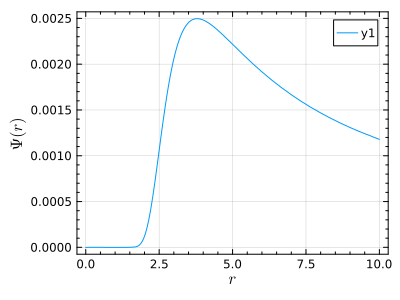

In [8]:
gemplot(gm_4he,gh_4he,gb_4he,1,1,0,10;legend=:topright,xlabel=L"r",ylabel=L"\Psi(r)")

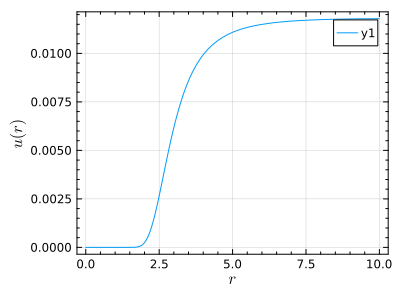

In [9]:
gemplotr(gm_4he,gh_4he,gb_4he,1,1,0,10;legend=:topright,xlabel=L"r",ylabel=L"u(r)")

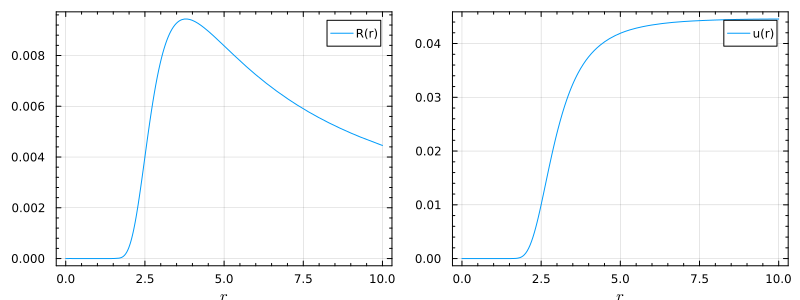

In [10]:
let 
    wfs=gemgetwf(gm_4he,gh_4he,gb_4he,1)

    p1=plot(legend=:topright,xlabel=L"r")
    for i in eachindex(wfs)
        plot!(r->wfs[i](r),0,10,label="R(r)")
    end
    p2=plot(legend=:topright,xlabel=L"r")   
    for i in eachindex(wfs)
        plot!(r->r*wfs[i](r),0,10,label="u(r)")
    end

    plot(p1,p2,layout=(1,2),size=(800,300))
end

## Test for deuteron

### pheonomenology formula

In [11]:
function potential_deuteron(r,i,j)
    if i==1&&j==1 #only for single-channel
        return (-626.885*exp(-1.55*r)+1438.72*exp(-3.11*r))/r
    end
    return 0.0
end

potential_deuteron (generic function with 1 method)

In [12]:
gb_deuteron=GemBasis(30,0.1,30.0)
gh_deuteron=GemHamiltonian([1.0],[0.0],[0],potential_deuteron)
gm_deuteron=GemModel(gh_deuteron,gb_deuteron;hbar=sqrt(2*41.47));

In [13]:
gemsolve!(gm_deuteron,gh_deuteron,gb_deuteron)

In [14]:
gemisbounded(gm_deuteron)

true

In [15]:
gm_deuteron.evals[1:10]

10-element Vector{ComplexF64}:
  -2.230606825912766 + 0.0im
 0.07698885397865293 + 0.0im
 0.31991781230906324 + 0.0im
  0.7674238708846295 + 0.0im
   1.493071389739311 + 0.0im
  2.6197206004226508 + 0.0im
   4.341874966799971 + 0.0im
   6.960495900919723 + 0.0im
  10.936368558155548 + 0.0im
  16.973005830054127 + 0.0im

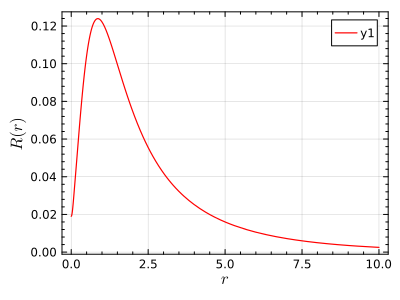

In [16]:
gemplot(gm_deuteron,gh_deuteron,gb_deuteron,1,1,0,10;color="red",lw=1.2,legend=:topright,xlabel=L"r",ylabel=L"R(r)")

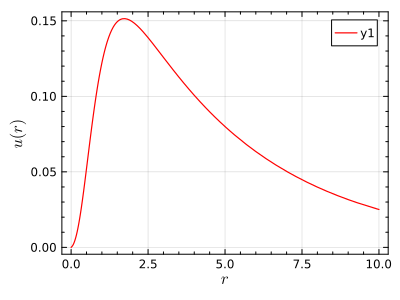

In [17]:
gemplotr(gm_deuteron,gh_deuteron,gb_deuteron,1,1,0,10;color="red",lw=1.2,legend=:topright,xlabel=L"r",ylabel=L"u(r)")

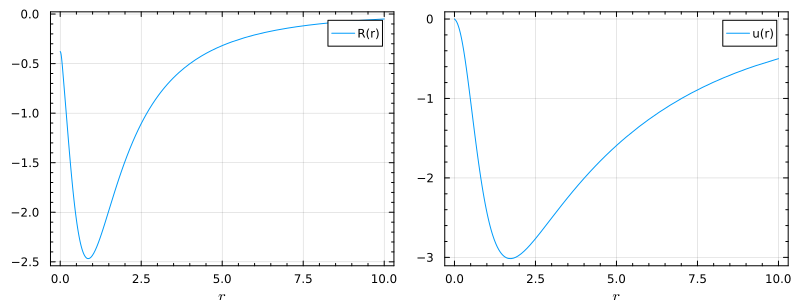

In [18]:
let 
    wfs=gemgetwf(gm_deuteron,gh_deuteron,gb_deuteron,1)

    p1=plot(legend=:topright,xlabel=L"r")
    for i in eachindex(wfs)
        plot!(r->wfs[i](r),0,10,label="R(r)")
    end
    p2=plot(legend=:topright,xlabel=L"r")   
    for i in eachindex(wfs)
        plot!(r->r*wfs[i](r),0,10,label="u(r)")
    end

    plot(p1,p2,layout=(1,2),size=(800,300))
end

there is an **extra** minus sign directly from the coefficients in this case.

### yukawa potential

In [19]:
μ_yukawa=0.140;mp_yukawa=0.938;mn_yukawa=0.939;hbarc=0.1973269804;

In [20]:
function potential_deuteron_yukawa(r,i,j;g=0.598189)
    r=r/hbarc
    if i==1&&j==1 #only for single-channel
        return -g^2*exp(-μ_yukawa*r)/r
    end
    return 0.0
end

potential_deuteron_yukawa (generic function with 1 method)

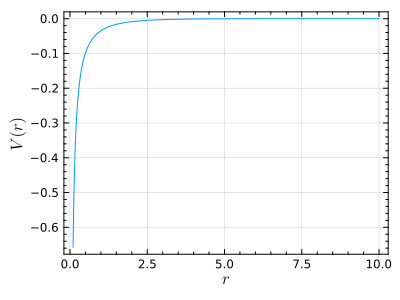

print device already activated


In [61]:
plot(r->potential_deuteron_yukawa(r,1,1),0.1,10;xlabel=L"r",ylabel=L"V(r)",legend=false)

In [21]:
gb_deuteron_yukawa=GemBasis(30,0.1,30.0)
gh_deuteron_yukawa=GemHamiltonian([mp_yukawa*mn_yukawa/(mp_yukawa+mn_yukawa)],[0.0],[0],potential_deuteron_yukawa)
gm_deuteron_yukawa=GemModel(gh_deuteron_yukawa,gb_deuteron_yukawa;hbar=hbarc);

In [22]:
gemsolve!(gm_deuteron_yukawa,gh_deuteron_yukawa,gb_deuteron_yukawa)

In [23]:
gemisbounded(gm_deuteron_yukawa)

true

In [24]:
gm_deuteron_yukawa.evals[1:10]

10-element Vector{ComplexF64}:
 -0.002228001993987076 + 0.0im
   7.67981214513973e-5 + 0.0im
 0.0003189997745818755 + 0.0im
 0.0007646474621778589 + 0.0im
 0.0014858762008774873 + 0.0im
 0.0026022407027493154 + 0.0im
  0.004301253556549834 + 0.0im
 0.0068691476609353255 + 0.0im
  0.010738325427941058 + 0.0im
  0.016557523337692507 + 0.0im

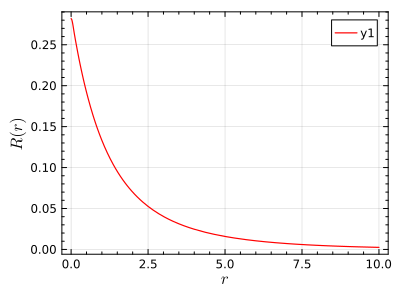

In [25]:
gemplot(gm_deuteron_yukawa,gh_deuteron_yukawa,gb_deuteron_yukawa,1,1,0,10;color="red",lw=1.2,legend=:topright,xlabel=L"r",ylabel=L"R(r)")

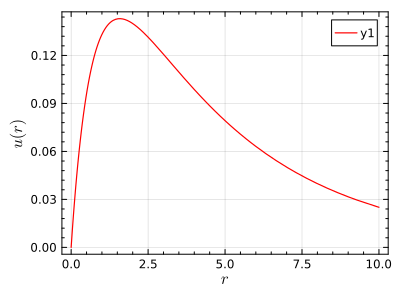

In [26]:
gemplotr(gm_deuteron_yukawa,gh_deuteron_yukawa,gb_deuteron_yukawa,1,1,0,10;color="red",lw=1.2,legend=:topright,xlabel=L"r",ylabel=L"u(r)")

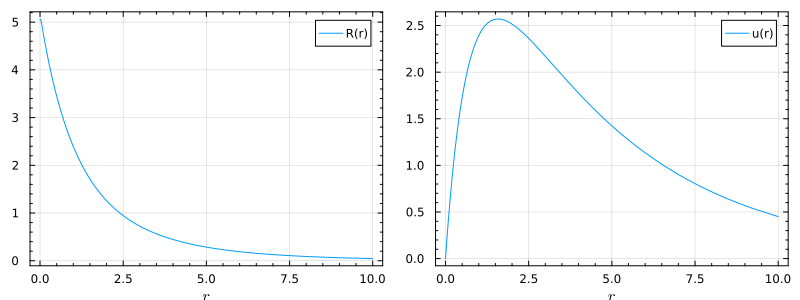

In [27]:

let 
    wfs=gemgetwf(gm_deuteron_yukawa,gh_deuteron_yukawa,gb_deuteron_yukawa,1)

    p1=plot(legend=:topright,xlabel=L"r")
    for i in eachindex(wfs)
        plot!(r->wfs[i](r),0,10,label="R(r)")
    end
    p2=plot(legend=:topright,xlabel=L"r")   
    for i in eachindex(wfs)
        plot!(r->r*wfs[i](r),0,10,label="u(r)")
    end

    plot(p1,p2,layout=(1,2),size=(800,300))
end

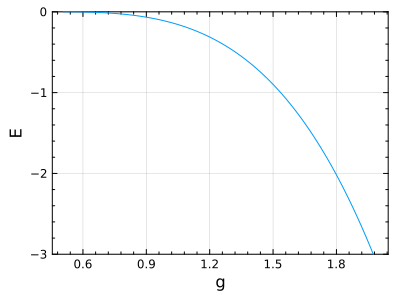

In [28]:
let 
    function E_g_dep(g)
        gb_deuteron_yukawa=GemBasis(30,0.1,30.0)
        gh_deuteron_yukawa=GemHamiltonian([mp_yukawa*mn_yukawa/(mp_yukawa+mn_yukawa)],[0.0],[0],(r,i,j) -> potential_deuteron_yukawa(r,i,j;g=g))
        gm_deuteron_yukawa=GemModel(gh_deuteron_yukawa,gb_deuteron_yukawa;hbar=hbarc)
        gemsolve!(gm_deuteron_yukawa,gh_deuteron_yukawa,gb_deuteron_yukawa)
        return gm_deuteron_yukawa.evals[1]
    end
    plot(0.5:0.01:2.0,g->real(E_g_dep(g)),xlabel="g",ylabel="E",legend=false,ylims=(-3.0,0.0))
end

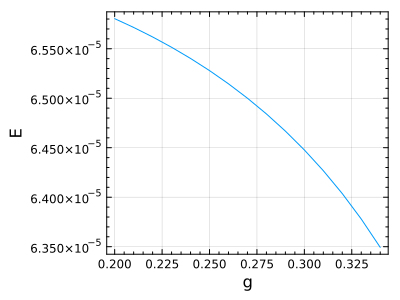

In [29]:
let 
    function E_g_dep(g)
        gb_deuteron_yukawa=GemBasis(30,0.1,30.0)
        gh_deuteron_yukawa=GemHamiltonian([mp_yukawa*mn_yukawa/(mp_yukawa+mn_yukawa)],[0.0],[0],(r,i,j) -> potential_deuteron_yukawa(r,i,j;g=g))
        gm_deuteron_yukawa=GemModel(gh_deuteron_yukawa,gb_deuteron_yukawa;hbar=hbarc)
        gemsolve!(gm_deuteron_yukawa,gh_deuteron_yukawa,gb_deuteron_yukawa)
        return gm_deuteron_yukawa.evals[1]
    end
    plot(0.2:0.01:0.34,g->real(E_g_dep(g)),xlabel="g",ylabel="E",legend=false)
end

### exponential potential

In [3]:
μ_exp=0.140;mp_exp=0.938;mn_exp=0.939;hbarc=0.1973269804;

In [4]:
function potential_deuteron_expo(r,i,j;U0=1.4132604267565418)
    r=r/hbarc
    μpn=mp_exp*mn_exp/(mp_exp+mn_exp)
    if i==1&&j==1 #only for single-channel
        return -U0*exp(-μ_exp*r)*hbarc^2/(2*μpn)
    end
    return 0.0
end

# function potential_deuteron_expo(r,i,j;V0=0.03489)
#     r=r/hbarc
#     if i==1&&j==1 #only for single-channel
#         return -V0*exp(-μ_exp*r)
#     end
#     return 0.0
# end

potential_deuteron_expo (generic function with 1 method)

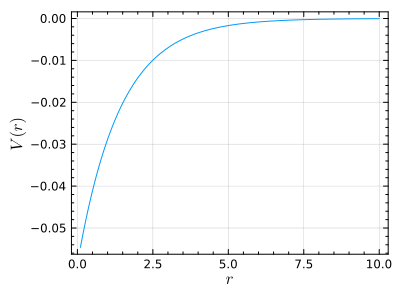

In [5]:
plot(r->potential_deuteron_expo(r,1,1),0.1,10;xlabel=L"r",ylabel=L"V(r)",legend=false)

In [6]:
gb_deuteron_expo=GemBasis(60,0.01,60.0)
gh_deuteron_expo=GemHamiltonian([mp_exp*mn_exp/(mp_exp+mn_exp)],[0.0],[0],potential_deuteron_expo)
gm_deuteron_expo=GemModel(gh_deuteron_expo,gb_deuteron_expo;hbar=hbarc);

In [7]:
gemsolve!(gm_deuteron_expo,gh_deuteron_expo,gb_deuteron_expo)

In [8]:
gemisbounded(gm_deuteron_expo)

true

In [9]:
gm_deuteron_expo.evals[1:10]

10-element Vector{ComplexF64}:
 -0.0022000000125840143 + 0.0im
  1.4379784620257367e-5 + 0.0im
   5.874298588246449e-5 + 0.0im
 0.00013691204494570937 + 0.0im
  0.0002556533990581778 + 0.0im
  0.0004254743863233273 + 0.0im
  0.0006619618555339253 + 0.0im
  0.0009872909102925456 + 0.0im
  0.0014321663077002734 + 0.0im
   0.002038966159290853 + 0.0im

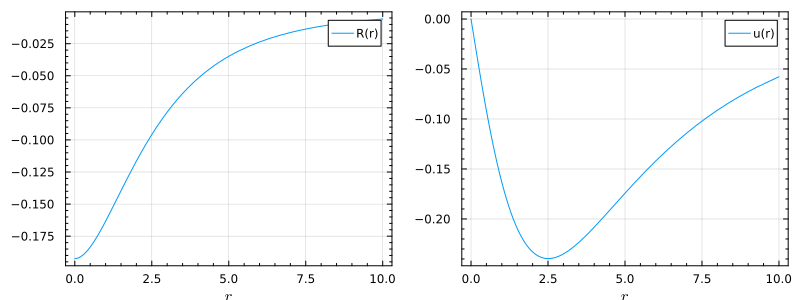

In [10]:
let 
    wfs=gemgetwf(gm_deuteron_expo,gh_deuteron_expo,gb_deuteron_expo,1)

    p1=plot(legend=:topright,xlabel=L"r")
    for i in eachindex(wfs)
        plot!(r->wfs[i](r),0,10,label="R(r)")
    end
    p2=plot(legend=:topright,xlabel=L"r")   
    for i in eachindex(wfs)
        plot!(r->r*wfs[i](r),0,10,label="u(r)")
    end

    plot(p1,p2,layout=(1,2),size=(800,300))
end

1.413260424569883


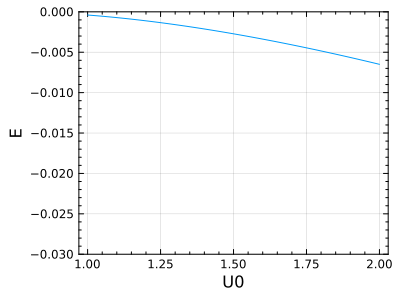

In [11]:
let 
    function E_g_dep(U0)
        gb_deuteron_expo=GemBasis(60,0.01,60.0)
        gh_deuteron_expo=GemHamiltonian([mp_exp*mn_exp/(mp_exp+mn_exp)],[0.0],[0],(r,i,j) -> potential_deuteron_expo(r,i,j;U0=U0))
        gm_deuteron_expo=GemModel(gh_deuteron_expo,gb_deuteron_expo;hbar=hbarc)
        gemsolve!(gm_deuteron_expo,gh_deuteron_expo,gb_deuteron_expo)
        return gm_deuteron_expo.evals[1]
    end
    println(Roots.find_zero(g->real(E_g_dep(g))+0.0022,(1.0,2.0)))
     plot(1.0:0.01:2.0,x->real(E_g_dep(x)),xlabel="U0",ylabel="E",legend=false,ylims=(-0.03,0.0))
end

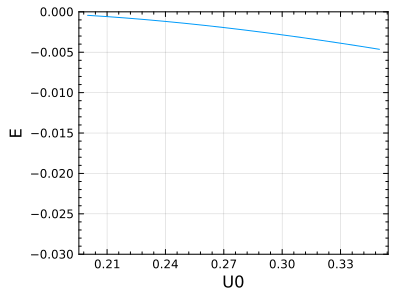

In [12]:
let 
    function E_g_dep(U0)
        gb_deuteron_expo=GemBasis(60,0.01,60.0)
        gh_deuteron_expo=GemHamiltonian([mp_exp*mn_exp/(mp_exp+mn_exp)],[0.0],[0],(r,i,j) -> potential_deuteron_expo(r,i,j;U0=U0))
        gm_deuteron_expo=GemModel(gh_deuteron_expo,gb_deuteron_expo;hbar=hbarc)
        gemsolve!(gm_deuteron_expo,gh_deuteron_expo,gb_deuteron_expo)
        return gm_deuteron_expo.evals[1]
    end
     plot(0.2:0.01:0.35,x->real(E_g_dep(x/hbarc)),xlabel="U0",ylabel="E",legend=false,ylims=(-0.03,0.0))
end

In [13]:
1/(0.134/hbarc)
# 2*mp_exp*mn_exp/(mp_exp+mn_exp)*0.035/hbarc^2

1.4725894059701492

#### solve ODE

In [20]:
using DifferentialEquations,BoundaryValueDiffEq,OrdinaryDiffEq;

In [21]:
function my_normalize(x,y)
    integral=sum((y[1:end - 1].^2) .* (abs.(x[2:end] - x[1:end - 1])))
    return y/sqrt(integral)
end

my_normalize (generic function with 1 method)

In [22]:
# function exponential_V!(du,u,p,r;U0=1.4132604267565418,μ=μ_exp)
#     U(r)=U0*exp(-μ*r/hbarc)
#     μpn=mp_exp*mn_exp/(mp_exp+mn_exp)
#     du[1]=u[2]
#     du[2]=-(U(r)+2*μpn/hbarc^2*p)*u[1]
# end

function exponential_V!(du, u, p, r)
    # p = [U0, E]
    U0, E = p
    mp = 0.938; mn = 0.939; hbarc = 0.1973269804; mpi = 0.14
    μpn = mp*mn/(mp+mn)      # correct reduced mass = 0.469197 GeV
    a   = hbarc/mpi          # range parameter = 1.40948 fm
    
    U(r) = U0 * exp(-r/a)    # U0 in fm^-2, r in fm
    
    du[1] = u[2]
    du[2] = -(U(r) + 2*μpn/hbarc^2 * E) * u[1]
end

exponential_V! (generic function with 1 method)

In [26]:
# let 
#     function integrate(rmax=50.0)
#         u0=big.([0.0,1.0])
#         prob(e)=ODEProblem(exponential_V!,u0,(1e-5,rmax),e)
#         solf(e)=solve(prob(e), Tsit5(), reltol=1e-8, abstol=1e-8)
#         e_eigen=find_zero(e->solf(e).u[end][1],(-1.0,-0.00001))
#         return e_eigen
#     end
    
#     for tmp in 20.0:10.0:300.0
#         print(integrate(tmp),"\n")
#     end
# end
let 
    function integrate(rmax=50.0)
        u0=big.([0.0,1.0])
        prob(e)=ODEProblem(exponential_V!,u0,(1e-5,rmax),e)
        solf(e)=solve(prob(e), Tsit5(), reltol=1e-8, abstol=1e-8)
        e_eigen=find_zero(e->solf([1.4132604267565418,e]).u[end][1],(-1.0,-0.00001))
        return e_eigen
    end
    
    for tmp in 20.0:10.0:300.0
        print(integrate(tmp),"\n")
    end
end

-0.002197524177291145
-0.0021999180925207362
-0.002199941938515715
-0.0021999421769091283
-0.002199942179292554
-0.002199942179316384
-0.0021999421793166226
-0.0021999421793166252
-0.0021999421793166252
-0.0021999421793166252
-0.0021999421793166252
-0.0021999421793166252
-0.0021999421793166252
-0.0021999421793166252
-0.0021999421793166252
-0.0021999421793166252
-0.0021999421793166252
-0.0021999421793166252
-0.0021999421793166252
-0.0021999421793166252
-0.0021999421793166252
-0.0021999421793166252
-0.0021999421793166252
-0.0021999421793166252
-0.0021999421793166252
-0.0021999421793166252
-0.0021999421793166252
-0.0021999421793166252
-0.0021999421793166252


The eigen energy is -0.002200000798686615


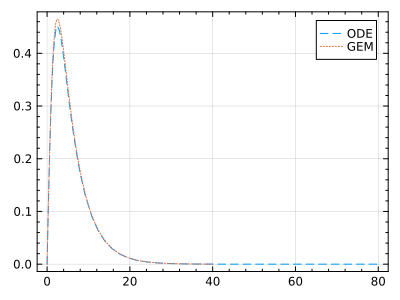

In [19]:
let 

    wfs=gemgetwf(gm_deuteron_expo,gh_deuteron_expo,gb_deuteron_expo,1)

    x_data_0=collect(0.0:0.01:40.0)
    y_data_0=[real(x*wfs[1](x)) for x in x_data_0]
    y_normalized=my_normalize(x_data_0,y_data_0)
    # plot(x_data_0,y_normalized,label="normalized data",ls=:dash)

f(x)=let u0=[0.0,x],rspan=(1e-10,80.0)
    
#     function condition(u,t,integrator) # Event when event_f(u,t) == 0
#       u[1]>10
#     end
    
#     function affect!(integrator)
#       integrator.u[2] = -integrator.u[2]
#     end
    
#     cb = ContinuousCallback(condition,affect!)
    
    prob(e)=ODEProblem(exponential_V!,u0,rspan,e)
    solf(e)=solve(prob(e), Tsit5(), reltol=1e-8, abstol=1e-8)
    e_eigen=find_zero(e->solf(e).u[end][1],(-1.0,-0.00001))
    
    sol=solf(e_eigen);
    print("The eigen energy is $e_eigen\n")   
    
    xdata=sol.t
    ydata=hcat(sol.u...)[1,:]
    nydata=my_normalize(xdata,ydata)
    plot(xdata,nydata,label="ODE",ls=:dash)
    plot!(x_data_0,-y_normalized,label="GEM",ls=:dot)
end
    # plot(f(1e-3),f(3e-3),f(6e-3),f(1e-2),layout=(2,2),size=(700,480))   
    f(1e-3)
end

# Try it yourself!